In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = load_breast_cancer()

X= pd.DataFrame(data.data, columns=data.feature_names)
y= pd.Series(data.target, name='target')

print('Feature matrix shape: ',X.shape)
print('Target shape: ', y.shape)

Feature matrix shape:  (569, 30)
Target shape:  (569,)


In [3]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [4]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, stratify=y)

X_train.shape, X_test.shape

((426, 30), (143, 30))

In [5]:
model= RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
pred= model.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy:  0.9230769230769231
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        53
           1       0.92      0.96      0.94        90

    accuracy                           0.92       143
   macro avg       0.92      0.91      0.92       143
weighted avg       0.92      0.92      0.92       143



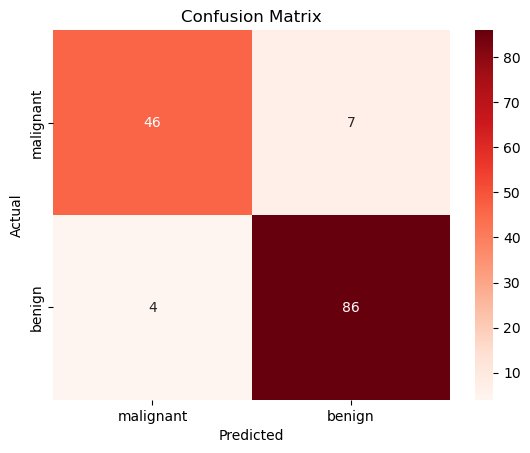

In [12]:
cm= confusion_matrix(y_test, pred)

plt.Figure(figsize=(10, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=data.target_names, yticklabels=data.target_names) # 1,2 এর বদলে real নাম দিতে চাইলে

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Random Forest Feature Importance

In [13]:
importances= pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

worst concave points    0.143403
worst area              0.129247
mean concave points     0.116991
worst radius            0.094026
mean perimeter          0.078548
worst perimeter         0.077524
mean concavity          0.072756
mean radius             0.045204
mean area               0.043626
worst concavity         0.038900
dtype: float64

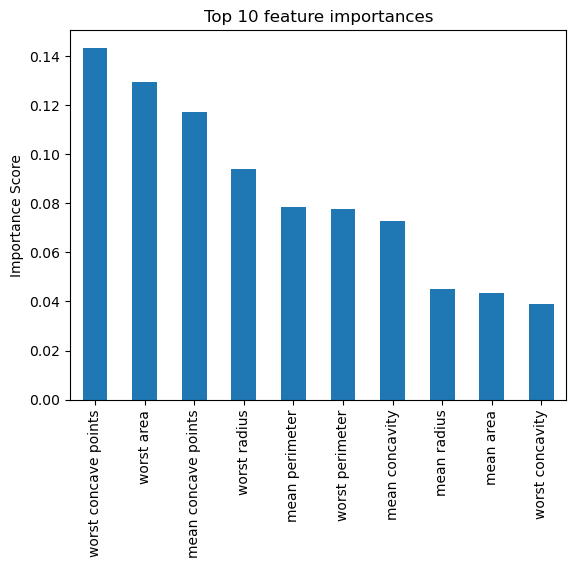

In [14]:
# visulaisation
plt.Figure(figsize=(10, 6))
importances.head(10).plot(kind='bar')
plt.title('Top 10 feature importances')
plt.ylabel('Importance Score')
plt.show()

# Apply GridSearchCV

In [15]:
param_grid={
    'n_estimators': [100, 150, 175, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 3, 5],
    'max_features': ['sqrt', 'log2']
}

In [16]:
grid_rf= GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1 # use all cpu core
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [100, 150, 175, 200]},
             scoring='f1')

In [17]:
print('Best paremeters found:')
print(grid_rf.best_params_)

Best paremeters found:
{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 150}


In [18]:
best_rf= grid_rf.best_estimator_
y_pred= best_rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.94      0.85      0.89        53
      benign       0.92      0.97      0.94        90

    accuracy                           0.92       143
   macro avg       0.93      0.91      0.92       143
weighted avg       0.92      0.92      0.92       143

